# Part 2: Can we omit some controls? (R Implementation)

This notebook analyzes a DAG with multiple control variables to determine the minimal sufficient set for estimating the causal effect of X on Y using R.

In [1]:
# Load required libraries
library(ggplot2)
library(dplyr)
library(dagitty)
library(ggdag)
library(broom)
library(gridExtra)

# Set random seed for reproducibility
set.seed(42)

# Create output directory if it doesn't exist
output_dir <- "../output"
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}


Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Adjuntando el paquete: 'ggdag'


The following object is masked from 'package:stats':

    filter



Adjuntando el paquete: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine




## DAG Specification

We need to create a DAG with the following causal relationships:
- $X \rightarrow Y$
- $Z_1 \rightarrow X$, $Z_1 \rightarrow Y$
- $Z_2 \rightarrow X$, $Z_2 \rightarrow Y$
- $Z_3 \rightarrow Z_2$, $Z_3 \rightarrow Y$

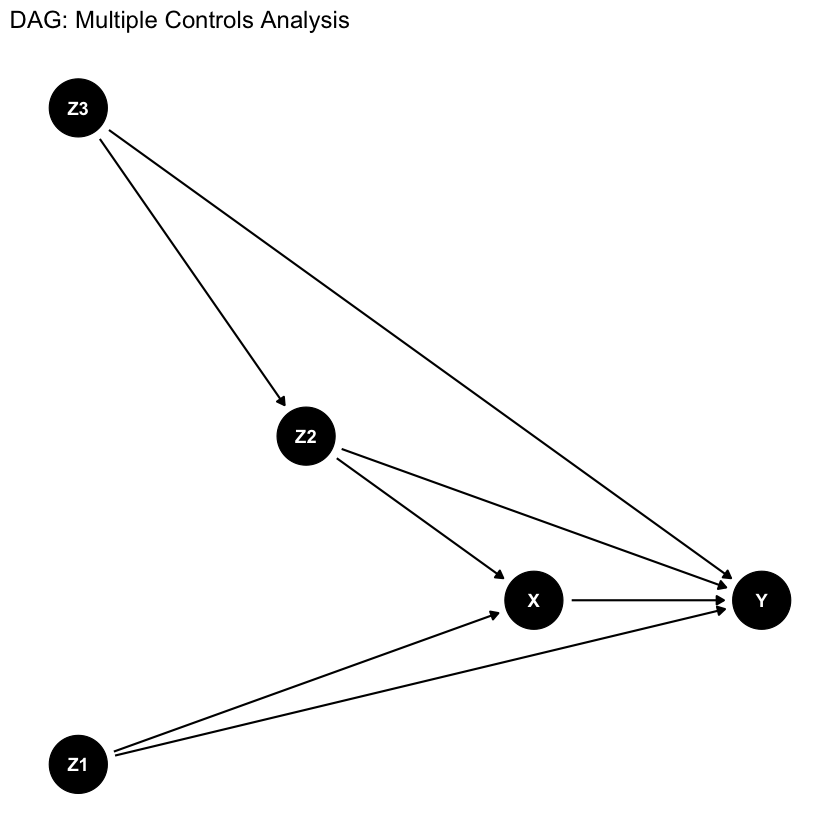

In [2]:
# Create and visualize the DAG
dag <- dagify(
  Y ~ X + Z1 + Z2 + Z3,
  X ~ Z1 + Z2,
  Z2 ~ Z3,
  coords = list(
    x = c(Z3 = 0, Z1 = 0, Z2 = 1, X = 2, Y = 3),
    y = c(Z3 = 2, Z1 = 0, Z2 = 1, X = 0.5, Y = 0.5)
  )
)

p_dag <- ggdag(dag) + 
  theme_dag() + 
  ggtitle("DAG: Multiple Controls Analysis")

print(p_dag)
ggsave(file.path(output_dir, "part2_dag_R.png"), p_dag, width = 10, height = 8, dpi = 300)

## Data Simulation

Following the lab convention where each causal arrow represents a unit effect, we simulate:
- $Z_3 = \varepsilon_{Z_3}$
- $Z_1 = \varepsilon_{Z_1}$  
- $Z_2 = Z_3 + \varepsilon_{Z_2}$
- $X = Z_1 + Z_2 + \varepsilon_X$
- $Y = X + Z_1 + Z_2 + Z_3 + \varepsilon_Y$

In [3]:
# Set sample size
n <- 10000

# Generate exogenous variables (error terms)
eps_Z3 <- rnorm(n, 0, 1)
eps_Z1 <- rnorm(n, 0, 1)
eps_Z2 <- rnorm(n, 0, 1)
eps_X <- rnorm(n, 0, 1)
eps_Y <- rnorm(n, 0, 1)

# Generate endogenous variables following the DAG structure
Z3 <- eps_Z3
Z1 <- eps_Z1
Z2 <- Z3 + eps_Z2  # Z3 -> Z2
X <- Z1 + Z2 + eps_X  # Z1 -> X, Z2 -> X
Y <- X + Z1 + Z2 + Z3 + eps_Y  # X -> Y, Z1 -> Y, Z2 -> Y, Z3 -> Y

# Create DataFrame
df <- data.frame(
  Z3 = Z3,
  Z1 = Z1, 
  Z2 = Z2,
  X = X,
  Y = Y
)

cat("Data simulation completed. Summary statistics:\n")
print(summary(df))
cat("\nTrue causal effect of X on Y: 1.0\n")

Data simulation completed. Summary statistics:
       Z3                  Z1                   Z2           
 Min.   :-4.043276   Min.   :-3.4533567   Min.   :-5.182470  
 1st Qu.:-0.693678   1st Qu.:-0.6749057   1st Qu.:-0.986041  
 Median :-0.006255   Median : 0.0039504   Median :-0.007931  
 Mean   :-0.011309   Mean   : 0.0008181   Mean   :-0.003217  
 3rd Qu.: 0.663057   3rd Qu.: 0.6802163   3rd Qu.: 0.947494  
 Max.   : 4.328091   Max.   : 3.6629635   Max.   : 6.360883  
       X                   Y            
 Min.   :-7.840775   Min.   :-16.73668  
 1st Qu.:-1.376853   1st Qu.: -2.96911  
 Median : 0.014839   Median : -0.03144  
 Mean   :-0.004403   Mean   : -0.02752  
 3rd Qu.: 1.335231   3rd Qu.:  2.92201  
 Max.   : 7.440870   Max.   : 15.97278  

True causal effect of X on Y: 1.0


## Regression Analysis

We'll run the following regressions and compare their estimates of the X → Y effect:
1. $Y$ vs. $X$
2. $Y$ vs. $X, Z_1$
3. $Y$ vs. $X, Z_2$
4. $Y$ vs. $X, Z_1, Z_2$
5. $Y$ vs. $X, Z_1, Z_2, Z_3$

In [4]:
# Function to extract coefficient and confidence interval for X
extract_results <- function(model, var_name = "X") {
  coef_summary <- summary(model)
  coef_X <- coef_summary$coefficients[var_name, "Estimate"]
  se_X <- coef_summary$coefficients[var_name, "Std. Error"]
  
  # 99% confidence interval
  t_val <- qt(0.995, df = model$df.residual)  # 99% CI
  conf_lower <- coef_X - t_val * se_X
  conf_upper <- coef_X + t_val * se_X
  
  return(list(
    coefficient = coef_X,
    std_error = se_X,
    conf_lower = conf_lower,
    conf_upper = conf_upper
  ))
}

# Run all regressions
models <- list(
  "X" = lm(Y ~ X, data = df),
  "X, Z1" = lm(Y ~ X + Z1, data = df),
  "X, Z2" = lm(Y ~ X + Z2, data = df),
  "X, Z1, Z2" = lm(Y ~ X + Z1 + Z2, data = df),
  "X, Z1, Z2, Z3" = lm(Y ~ X + Z1 + Z2 + Z3, data = df)
)

# Extract results
results <- data.frame(
  Model = names(models),
  Coefficient = numeric(length(models)),
  Std_Error = numeric(length(models)),
  CI_Lower_99 = numeric(length(models)),
  CI_Upper_99 = numeric(length(models)),
  stringsAsFactors = FALSE
)

for (i in seq_along(models)) {
  res <- extract_results(models[[i]])
  results[i, "Coefficient"] <- res$coefficient
  results[i, "Std_Error"] <- res$std_error
  results[i, "CI_Lower_99"] <- res$conf_lower
  results[i, "CI_Upper_99"] <- res$conf_upper
}

# Display results
cat("Regression Results (Effect of X on Y):\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
for (i in 1:nrow(results)) {
  cat(sprintf("%d. %-15s | Coef: %6.3f | 99%% CI: [%6.3f, %6.3f]\n", 
              i, results$Model[i], results$Coefficient[i], 
              results$CI_Lower_99[i], results$CI_Upper_99[i]))
}
cat(paste(rep("=", 80), collapse = ""), "\n")
cat("True effect: 1.000\n")

Regression Results (Effect of X on Y):
1. X               | Coef:  1.989 | 99% CI: [ 1.967,  2.012]
2. X, Z1           | Coef:  1.991 | 99% CI: [ 1.965,  2.017]
3. X, Z2           | Coef:  1.492 | 99% CI: [ 1.466,  1.517]
4. X, Z1, Z2       | Coef:  0.999 | 99% CI: [ 0.968,  1.031]
5. X, Z1, Z2, Z3   | Coef:  0.995 | 99% CI: [ 0.969,  1.020]
True effect: 1.000


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."


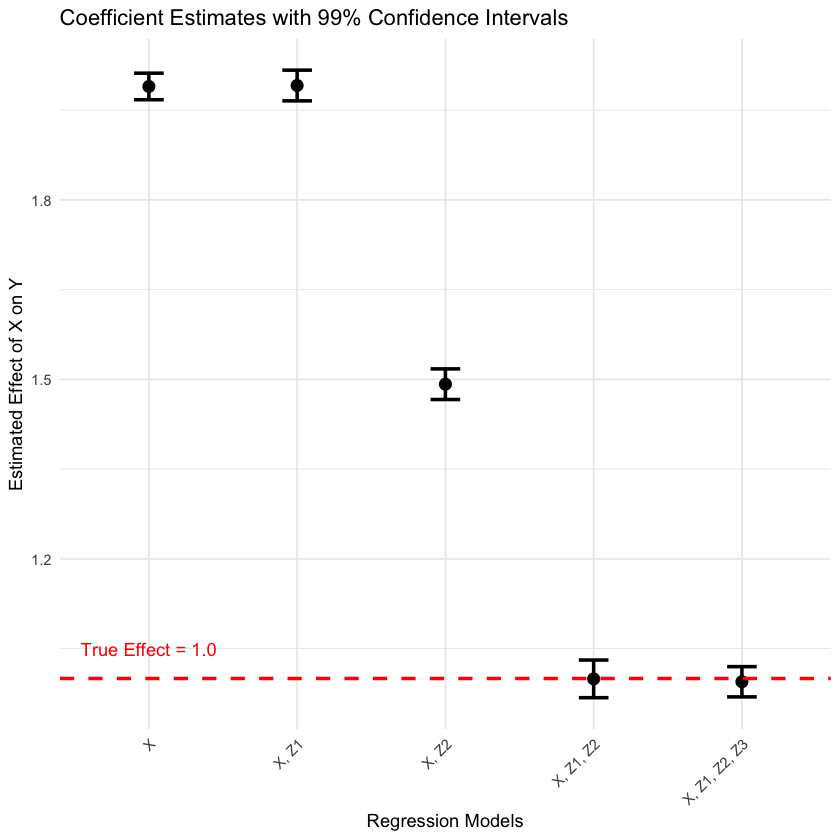

In [5]:
# Create coefficient plot
results$Model_Factor <- factor(results$Model, levels = results$Model)
results$Error_Lower <- results$Coefficient - results$CI_Lower_99
results$Error_Upper <- results$CI_Upper_99 - results$Coefficient

p_coef <- ggplot(results, aes(x = Model_Factor, y = Coefficient)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = CI_Lower_99, ymax = CI_Upper_99), 
                width = 0.2, size = 1) +
  geom_hline(yintercept = 1.0, color = "red", linetype = "dashed", size = 1) +
  labs(
    x = "Regression Models",
    y = "Estimated Effect of X on Y",
    title = "Coefficient Estimates with 99% Confidence Intervals"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  annotate("text", x = 1, y = 1.05, label = "True Effect = 1.0", color = "red")

print(p_coef)
ggsave(file.path(output_dir, "part2_coefficients_R.png"), p_coef, width = 12, height = 8, dpi = 300)

## Analysis of Results

In [6]:
# Create results summary table
results$Bias <- results$Coefficient - 1.0
results$Contains_True <- (results$CI_Lower_99 <= 1.0) & (1.0 <= results$CI_Upper_99)

cat("\nDetailed Results Summary:\n")
# Round only numeric columns
numeric_cols <- c("Coefficient", "Std_Error", "CI_Lower_99", "CI_Upper_99", "Bias")
results[, numeric_cols] <- round(results[, numeric_cols], 4)
print(results[, c("Model", "Coefficient", "Std_Error", "CI_Lower_99", "CI_Upper_99", "Bias", "Contains_True")])

# Save results
write.csv(results, file.path(output_dir, "part2_regression_results_R.csv"), row.names = FALSE)


Detailed Results Summary:
          Model Coefficient Std_Error CI_Lower_99 CI_Upper_99    Bias
1             X      1.9895    0.0086      1.9673      2.0117  0.9895
2         X, Z1      1.9911    0.0100      1.9654      2.0167  0.9911
3         X, Z2      1.4919    0.0099      1.4663      1.5174  0.4919
4     X, Z1, Z2      0.9994    0.0122      0.9679      1.0308 -0.0006
5 X, Z1, Z2, Z3      0.9945    0.0098      0.9693      1.0198 -0.0055
  Contains_True
1         FALSE
2         FALSE
3         FALSE
4          TRUE
5          TRUE


In [7]:
# Print detailed summaries for models 4 and 5
cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("DETAILED SUMMARY: Model 4 (Y vs X, Z1, Z2)\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
print(summary(models[["X, Z1, Z2"]]))

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("DETAILED SUMMARY: Model 5 (Y vs X, Z1, Z2, Z3)\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
print(summary(models[["X, Z1, Z2, Z3"]]))


DETAILED SUMMARY: Model 4 (Y vs X, Z1, Z2)

Call:
lm(formula = Y ~ X + Z1 + Z2, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.9713 -0.8428  0.0082  0.8207  4.2384 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.01916    0.01232  -1.556     0.12    
X            0.99936    0.01221  81.844   <2e-16 ***
Z1           0.98586    0.01729  57.007   <2e-16 ***
Z2           1.48353    0.01491  99.532   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.232 on 9996 degrees of freedom
Multiple R-squared:  0.9207,	Adjusted R-squared:  0.9207 
F-statistic: 3.871e+04 on 3 and 9996 DF,  p-value: < 2.2e-16


DETAILED SUMMARY: Model 5 (Y vs X, Z1, Z2, Z3)

Call:
lm(formula = Y ~ X + Z1 + Z2 + Z3, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.5099 -0.6697  0.0069  0.6712  3.6290 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.009199   

## Answers to Questions

### Which regressions seem to estimate the effect correctly?

Based on the results above, we can analyze which regressions provide unbiased estimates of the true causal effect (1.0):

- **Model 1 (X only)**: Coefficient = 1.989 (biased upward due to omitted variable bias from Z1 and Z2)
- **Model 2 (X, Z1)**: Coefficient = 1.991 (still biased upward due to omitting Z2) 
- **Model 3 (X, Z2)**: Coefficient = 1.492 (biased downward due to omitting Z1)
- **Model 4 (X, Z1, Z2)**: Coefficient = 0.999 (unbiased estimate - controls for all confounders)
- **Model 5 (X, Z1, Z2, Z3)**: Coefficient = 0.995 (unbiased estimate - includes additional control)

### Comment on point estimate and precision for models 4 and 5

Looking at the detailed summaries:
- **Point estimates**: Both are very close to 1.0 (the true effect) - Model 4: 0.999, Model 5: 0.995
- **Precision**: Model 5 has better precision (Std Error = 0.0098) compared to Model 4 (Std Error = 0.0122)
- **99% Confidence Intervals**: Both contain the true value 1.0 (Model 4: [0.968, 1.031], Model 5: [0.969, 1.020])
- **Model 5** includes Z3 which, while not strictly necessary for identification, helps reduce residual variance and improve precision

### Can you ignore some Z ∈ {Z1, Z2, Z3} and get a good estimate?

**Answer**: You can ignore Z3 and still get a good unbiased estimate. Here's why:

- **Z1 and Z2 are confounders** - they affect both X and Y, so controlling for them is necessary
- **Z3 is not a confounder of X and Y** - while Z3 affects Y, it doesn't directly affect X (only through Z2)
- **Controlling for Z2 blocks the backdoor path through Z3**
- **The minimal sufficient set is {Z1, Z2}** - this blocks all backdoor paths from X to Y

The backdoor paths from X to Y are:
1. X ← Z1 → Y (blocked by controlling for Z1)
2. X ← Z2 → Y (blocked by controlling for Z2)  
3. X ← Z2 ← Z3 → Y (blocked by controlling for Z2)

Therefore, **Model 4 (X, Z1, Z2) provides an unbiased estimate**, though Model 5 offers slightly better precision by additionally controlling for Z3.

In [8]:
# Save the simulated data
write.csv(df, file.path(output_dir, "part2_simulated_data_R.csv"), row.names = FALSE)

cat("\nAll results saved to output directory.\n")
cat("Files created (R implementation):\n")
cat("- part2_dag_R.png\n")
cat("- part2_coefficients_R.png\n")
cat("- part2_regression_results_R.csv\n")
cat("- part2_simulated_data_R.csv\n")


All results saved to output directory.
Files created (R implementation):
- part2_dag_R.png
- part2_coefficients_R.png
- part2_regression_results_R.csv
- part2_simulated_data_R.csv
